# 06 — Mixed-Frequency DFM Nowcasting

**Thesis:** *Nowcasting and Indicator Selection in a Data-Rich Environment: An Application to German GDP Growth*

Part II of the thesis: nowcast German quarterly GDP growth with a mixed-frequency Dynamic Factor Model (DFM) on the indicator sets from `05_build_model_inputs.ipynb`.

## Notebook map

| Section | Content |
|---|---|
| **§0** | Imports, paths, run guards |
| **§1** | Load panels, GDP target, selection matrices |
| **§1b** | Ragged-edge diagnostics |
| **§2** | Factor-number diagnostic → fix `K = 2` |
| **§3** | A-CD-TPN nowcast loop (headline: DFM-EN) |
| **§4** | RW and AR(1) benchmarks |
| **§5** | Point-forecast evaluation (RMSFE, NSR, DM) |
| **§6** | Category contributions (ifoCAST-style) |
| **§7** | Integrated DFM-SV ($k=2$) |
| **§8** | Post-notebook CLI scripts |

## Nowcasting pipeline (two-stage ragged-edge fill)

At each **monthly** forecast origin $t$ (M1, M2, or M3 of target quarter $Q(t)$):

1. **Real-time masking** (`ragged_edge.apply_pub_lag_mask`): series $j$ observed only through $t - \ell_j$.
2. **AR($p$) BIC fill** (`ragged_edge.fill_ragged_edge_ar`): NaN months within $Q(t)$ filled from observed history only ($p \leq 4$).
3. **DynamicFactorMQ** (statsmodels ≥0.14): Mariano–Murasawa (2003) mixed-frequency encoding; Kalman smoother imputes missing GDP.
4. **Nowcast extraction**: `predict()` at the quarter-end month of $Q(t)$.

Three nowcasts per target quarter (**M1** → **M2** → **M3**) as more hard data arrive. Factor dynamics: VAR($p$) with $p = 2$ (`FACTOR_ORDER`); number of factors fixed at **$K = 2$** (§2).

### Models in this notebook

| Label | Role |
|---|---|
| **DFM-EN** (`en_only`) | Headline A-CD-TPN specification |
| **core**, **pls_only** | Sensitivity input sets (`RUN_SENSITIVITY_SETS = True`) |
| **RW**, **AR(1)** | Naive benchmarks |
| **DFM-SV-k2** | Headline distributional model (§7) |

### Evaluation (§5–§7)

* Window: **2011Q1 – 2025Q4**; headline metric: **M3** nowcasts.
* Point metrics: RMSFE, NSR, vs AR(1), Diebold–Mariano (HLN).
* Distributional metrics (SV): empirical PI coverage, mean PI width, CRPS.
* Cross-model tables: `scripts/pipelines/dfm/build_unified_evaluation.py`.

### References

* Bąnbura et al. (2013); Diebold & Mariano (1995); Doz, Giannone & Reichlin (2011); Giannone, Reichlin & Small (2008); Mariano & Murasawa (2003).


## 0. Setup

Imports, project paths, evaluation window, and **run guards**. Completed model CSVs are loaded by default; set `FORCE_RERUN = True` (or `FORCE_RERUN_SV` / `FORCE_RERUN_CONTRIB`) only when you intentionally re-fit.


In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Portable repository setup ---
_repo = next(
    (base for base in (Path.cwd(), *Path.cwd().parents)
     if (base / "src" / "german_gdp_nowcasting").is_dir()),
    None,
)
if _repo is None:
    raise RuntimeError("Could not locate src/german_gdp_nowcasting.")
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from german_gdp_nowcasting.config import paths as _tp
from german_gdp_nowcasting.models.dfm.nowcast_utils import (
    run_actpn_nowcast_loop,
    run_ar1_baseline,
    run_rw_baseline,
    compute_rmsfe,
    compute_rmsfe_by_month_in_quarter,
    _subset_eval_window,
    expand_quarterly_nowcasts_to_monthly,
    align_forecast_errors,
    diebold_mariano_test,
    eigenvalue_ratio_er,
    bai_ng_ic2,
    quarter_end_timestamp,
    build_interval_calibration_table,
    save_nowcast_outputs,
    nowcast_for_origin,
    get_current_quarter,
)
from german_gdp_nowcasting.models.dfm.ragged_edge import get_information_set_summary
from german_gdp_nowcasting.selection.core_utils import (
    load_monthly_panel,
    load_pub_lag_map,
    build_coverage_mask,
    make_monthly_forecast_origins,
)
from german_gdp_nowcasting.visualization import nowcast_plots as npl

npl.setup_style()
OUT_DIR = _tp.OUT_NOWCASTING
FIG_DIR = _tp.NOWCAST_FIGURES_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
EVAL_START = '2011Q1'
EVAL_END = '2025Q4'
HEADLINE_MIQ = 3   # M3 end-of-quarter nowcast (thesis headline metric)
HEADLINE_INPUT_SET = 'en_only'   # DFM-EN — thesis headline A-CD-TPN spec
RUN_SENSITIVITY_SETS = False     # set True to also run core / pls_only
K_FACTORS = 2          # see §2 diagnostic
FACTOR_ORDER = 2       # AR(2) factor dynamics (ifoCAST)
# Expensive model and sensitivity runs are opt-in.
FORCE_RERUN = False
FORCE_RERUN_CONTRIB = False
FORCE_RERUN_SV = False

def _needs_run(csv_path) -> bool:
    """Return True if csv_path is missing or FORCE_RERUN is set."""
    return FORCE_RERUN or not Path(csv_path).exists()

def _needs_run_sv(csv_path) -> bool:
    """Return True if SV CSV is missing, forced, or stale (no month_in_quarter)."""
    if FORCE_RERUN_SV or FORCE_RERUN or not Path(csv_path).exists():
        return True
    head = pd.read_csv(csv_path, nrows=3)
    return "month_in_quarter" not in head.columns

def _load_nowcast_csv(csv_path: Path) -> pd.DataFrame:
    """Load nowcast results; prefer monthly_origin index when M1–M3 present."""
    df = pd.read_csv(csv_path)
    if "month_in_quarter" in df.columns and "monthly_origin" in df.columns:
        return df.set_index("monthly_origin")
    return df.set_index("quarter")

print(f'Window: {EVAL_START} → {EVAL_END}')


## 1. Load inputs

Loads from `05_build_model_inputs.ipynb` and upstream data preparation:

* **Monthly panel** — transformed indicators (`PANEL_TRANSFORMED_CSV`)
* **GDP target** — quarterly growth (`GDP_TARGET_CSV`)
* **Publication-lag map** — series-specific release delays
* **Selection matrices** — binary origin × series for `core`, `en_only`, `pls_only`

**Headline spec:** `en_only` → **DFM-EN**. The other two sets are sensitivity variants (off by default).


In [2]:
X_monthly   = load_monthly_panel(_tp.PANEL_TRANSFORMED_CSV)
pub_lag_map = load_pub_lag_map(_tp.PUB_LAG_CSV)
y_quarterly = pd.read_csv(_tp.GDP_TARGET_CSV, index_col='quarter').squeeze('columns')
y_quarterly.index = pd.PeriodIndex(y_quarterly.index, freq='Q')
y_quarterly = y_quarterly.astype(float)
INPUT_SET_PATHS = {
    'core':     _tp.CORE_MATRIX_CSV,
    'en_only':  _tp.EN_ONLY_MATRIX_CSV,
    'pls_only': _tp.PLS_ONLY_MATRIX_CSV,
}
selection_matrices = {
    k: pd.read_csv(v, index_col='forecast_origin').astype(int)
    for k, v in INPUT_SET_PATHS.items()
}
forecast_origins = make_monthly_forecast_origins('2011-01', '2025-12')
coverage_mask    = build_coverage_mask(X_monthly, forecast_origins, min_coverage=0.30)
quarterly_origins = pd.period_range(EVAL_START, EVAL_END, freq='Q')
print(f'Monthly panel  : {X_monthly.shape[0]} months x {X_monthly.shape[1]} series')
print(f'GDP target     : {len(y_quarterly)} quarters ({y_quarterly.index[0]} -> {y_quarterly.index[-1]})')
print(f'Pub-lag map    : {len(pub_lag_map)} series  (range {int(pub_lag_map.min())}-{int(pub_lag_map.max())} months)')
print(f'Quarterly eval : {len(quarterly_origins)} quarters')
print('\nInput sets:')
for k, m in selection_matrices.items():
    s = m.sum(axis=1)
    print(f'  {k:9s}: {m.shape[0]} origins x {m.shape[1]} cols | mean={s.mean():5.1f}  min={int(s.min())}  max={int(s.max())}')

Monthly panel  : 420 months x 585 series
GDP target     : 139 quarters (1991Q2 -> 2025Q4)
Pub-lag map    : 585 series  (range 0-2 months)
Quarterly eval : 60 quarters

Input sets:
  core     : 180 origins x 585 cols | mean= 31.4  min=26  max=38
  en_only  : 180 origins x 585 cols | mean= 53.4  min=40  max=69
  pls_only : 180 origins x 585 cols | mean= 30.0  min=30  max=30


## 1b. Ragged-edge diagnostics

Spot-check the information set at M1/M2/M3 of **2011Q1**. Expect fewer fully observed series at M1 than M3, and `n_filled_q > 0` for lag-1/lag-2 series at early-month origins.


In [ ]:
# Validate information set at M1/M2/M3 of 2011Q1.
# No-run guard: only when FORCE_RERUN=True or CSV absent.
_diag_origins = ['2011-01', '2011-02', '2011-03']
for _orig in _diag_origins:
    _summ = get_information_set_summary(X_monthly, _orig, pub_lag_map)
    _counts = _summ['status'].value_counts()
    print(f"{_orig}: "
          f"fully_observed={_counts.get('fully_observed',0)}  "
          f"ar_filled={_counts.get('ar_filled',0)}  "
          f"partially_missing={_counts.get('partially_missing',0)}")
# Spot-check: lag-2 series at M1 must have n_filled_q > 0
_m1_summ = get_information_set_summary(X_monthly, '2011-01', pub_lag_map)
_lag2 = _m1_summ[_m1_summ['pub_lag'] == 2].head(5)
print('\nLag-2 series at 2011-01 (M1):')
print(_lag2[['pub_lag', 'last_obs_month', 'n_obs_q', 'n_filled_q', 'n_missing_q', 'status']])
# Persist to diagnostics folder
_tp.RAGGED_EDGE_DIAG_DIR.mkdir(parents=True, exist_ok=True)
_m1_summ.to_csv(_tp.RAGGED_EDGE_DIAG_CSV)
print(f'\nDiagnostics -> {_tp.RAGGED_EDGE_DIAG_CSV}')


## 2. Factor number — diagnostic, then fix `K = 2`

Bai–Ng IC2 (2002) and Ahn–Horenstein (2013) eigenvalue-ratio estimates are computed at three sample origins as **appendix diagnostics only**. Production nowcasts use **`K_FACTORS = 2`**, consistent with ifoCAST (Lehmann, Reif & Wollmershäuser 2020). Factor 1 is a stable real-activity composite (production, turnover, orders and trade). Factor 2 is mixed: surveys are the largest single category, but production, turnover and orders still account for about two-thirds of its loading mass. Factors are identified only up to rotation and sign.


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
diag_rows = []
for q in [quarterly_origins[0], quarterly_origins[len(quarterly_origins)//2], quarterly_origins[-1]]:
    m3 = pd.Period(quarter_end_timestamp(q), freq='M')
    sel_cols = selection_matrices['core'].columns[
        selection_matrices['core'].loc[str(m3)].astype(bool)
    ].tolist()
    X_train = X_monthly[sel_cols].loc[X_monthly.index <= m3.to_timestamp()]
    X_arr = StandardScaler().fit_transform(SimpleImputer(strategy='mean').fit_transform(X_train.dropna(how='all').values))
    diag_rows.append({
        'quarter': str(q),
        'N': len(sel_cols),
        'IC2': bai_ng_ic2(X_arr, max_k=8),
        'ER':  eigenvalue_ratio_er(X_arr, max_k=8),
    })
pd.DataFrame(diag_rows).set_index('quarter')


## 3. A-CD-TPN — DFM nowcast loop (headline: DFM-EN)

By default only the headline input set (`en_only`) is fit. Existing results load from `outputs/nowcasting/`; nothing re-runs unless the CSV is missing or `FORCE_RERUN = True`.

Set `RUN_SENSITIVITY_SETS = True` in §0 to also run `core` and `pls_only`.

Per monthly origin: selection matrix → pub-lag mask + AR fill → `DynamicFactorMQ` ($K=2$) → Kalman nowcast.

> Saved headline file: `nowcast_results_actpn_en_only.csv`


In [5]:
actpn_results: dict[str, pd.DataFrame] = {}
INPUT_SETS_TO_RUN: list[str] = [HEADLINE_INPUT_SET]
if RUN_SENSITIVITY_SETS:
    INPUT_SETS_TO_RUN.extend(k for k in ('core', 'pls_only') if k != HEADLINE_INPUT_SET)

for key in INPUT_SETS_TO_RUN:
    mat = selection_matrices[key]
    csv = _tp.actpn_results_csv(key)
    if _needs_run(csv):
        print(f'\n=== A-CD-TPN | input set: {key} ===')
        df = run_actpn_nowcast_loop(
            selection_matrix=mat,
            X_monthly=X_monthly,
            y_quarterly=y_quarterly,
            quarterly_origins=quarterly_origins,
            factor_order=FACTOR_ORDER,
            idiosyncratic_ar1=True,
            maxiter=200,
            k_factors=K_FACTORS,
            verbose=False,
            pub_lag_map=pub_lag_map,
            fill_method='ar_bic',
            ar_max_p=4,
            ar_min_train=24,
        )
        df.to_csv(csv)
        actpn_results[key] = df
        r3 = compute_rmsfe(df, month_in_quarter=HEADLINE_MIQ)
        rp = compute_rmsfe(df)
        print(f'  RMSFE M{HEADLINE_MIQ} = {r3:.4f}  |  pooled M1-M3 = {rp:.4f}  |  saved -> {csv.name}')
    else:
        actpn_results[key] = _load_nowcast_csv(csv)
        _d = actpn_results[key]
        print(f'Loaded {csv.name}  (RMSFE M{HEADLINE_MIQ} = {compute_rmsfe(_d, month_in_quarter=HEADLINE_MIQ):.4f}; pooled = {compute_rmsfe(_d):.4f})')

# Optional: load sensitivity CSVs without re-running when files exist
for key in ('core', 'pls_only'):
    if key in actpn_results or key in INPUT_SETS_TO_RUN:
        continue
    csv = _tp.actpn_results_csv(key)
    if csv.exists():
        actpn_results[key] = _load_nowcast_csv(csv)
        _d = actpn_results[key]
        print(f'Loaded {csv.name} (sensitivity, not in INPUT_SETS_TO_RUN)')


Loaded nowcast_results_actpn_en_only.csv  (RMSFE M3 = 0.9811; pooled = 1.5042)


## 4. Univariate benchmarks

Two naive benchmarks alongside the A-CD-TPN models:

* **RW** — $\hat{y}_q = y_{q-1}$ (Stock & Watson 2002; Franjic & Schweikert 2025).
* **AR(1)** — $y_q = c + \phi y_{q-1} + \varepsilon_q$, OLS on the expanding window (universal sanity check).


In [6]:
if _needs_run(_tp.AR1_RESULTS_CSV):
    ar1_df = run_ar1_baseline(y_quarterly, quarterly_origins, train_start_quarter='1991Q1')
    ar1_df.to_csv(_tp.AR1_RESULTS_CSV)
else:
    ar1_df = pd.read_csv(_tp.AR1_RESULTS_CSV, index_col='quarter')
if _needs_run(_tp.RW_RESULTS_CSV):
    rw_df = run_rw_baseline(y_quarterly, quarterly_origins)
    rw_df.to_csv(_tp.RW_RESULTS_CSV)
else:
    rw_df = pd.read_csv(_tp.RW_RESULTS_CSV, index_col='quarter')
# Same quarterly forecast at M1/M2/M3 (for aligned DM tests; RMSFE at M3 unchanged).
ar1_df = expand_quarterly_nowcasts_to_monthly(ar1_df)
rw_df = expand_quarterly_nowcasts_to_monthly(rw_df)
print(f'AR(1)     RMSFE M{HEADLINE_MIQ} = {compute_rmsfe(ar1_df, month_in_quarter=HEADLINE_MIQ):.4f}')
print(f'RW        RMSFE M{HEADLINE_MIQ} = {compute_rmsfe(rw_df, month_in_quarter=HEADLINE_MIQ):.4f}')

AR(1)     RMSFE M3 = 2.4058
RW        RMSFE M3 = 2.9219


## 5. Point-forecast evaluation

**Window:** 2011Q1–2025Q4 (60 quarters). **Headline metric:** M3 nowcasts.

| Subsection | Output |
|---|---|
| **5a** (below) | RMSFE table — M3, pooled M1–M3, vs AR(1), NSR, DM $p$ vs AR(1) |
| **5b** | RMSFE by month-in-quarter (M1 vs M2 vs M3) |
| **5c** | Sub-period accuracy (pre-COVID / COVID / post-COVID) |
| **5d** | Selection composition heatmap |
| **5e** | Full pairwise Diebold–Mariano matrix |

**Notes:** The retired two-stage Bayesian SV only rescaled intervals. The headline **integrated** DFM-SV re-smooths with time-varying $Q_t$, so the point nowcast can differ slightly from DFM-EN (full-sample RMSFE 0.781 against 0.784). Canonical tables: `scripts/pipelines/dfm/build_unified_evaluation.py`. Some stored cell outputs in this notebook predate the 60-series elastic-net cap; cite the thesis tables (DFM-EN M3 RMSFE 0.784, not a printed 0.981 from an earlier run).


In [ ]:
# RMSFE summary: A-CD-TPN sets + benchmarks + SV variants vs AR(1).
# SV results are loaded here if already available; otherwise only the non-SV models
# are included and SV is added to the table when §7 has been run.
def _load_sv_if_ready(csv_path):
    """Load SV results CSV if it exists and has M1–M3 columns, else return None."""
    try:
        p = csv_path if hasattr(csv_path, 'exists') else Path(csv_path)
        if p.exists() and not _needs_run_sv(p):
            return _load_nowcast_csv(p)
    except Exception:
        pass
    return None
all_results: dict[str, pd.DataFrame] = {
    **actpn_results,
    'RW':   rw_df,
    'AR1':  ar1_df,
}
# Merge headline SV (produced in §7) when available
_df = _load_sv_if_ready(_tp.ACTPN_SV_RESULTS_K2_CSV)
if _df is not None:
    all_results['SV_k2'] = _df
REF_MODEL = 'AR1'
rmsfe = pd.Series({
    k: compute_rmsfe(d, eval_start=EVAL_START, eval_end=EVAL_END, month_in_quarter=HEADLINE_MIQ)
    for k, d in all_results.items()
}, name='RMSFE_M3')
rmsfe_pooled = pd.Series({
    k: compute_rmsfe(d, eval_start=EVAL_START, eval_end=EVAL_END)
    for k, d in all_results.items()
    if 'month_in_quarter' in d.columns
}, name='RMSFE_pooled')
rel_vs_ref = (rmsfe / rmsfe[REF_MODEL]).rename(f'vs {REF_MODEL}')
# Noise-to-Signal Ratio: RMSFE / std(GDP actuals) — practical relevance threshold
# NSR < 1 means forecast errors are smaller than GDP variability (ifoCAST paper p. 8)
gdp_std = float(y_quarterly.reindex(
    pd.period_range(EVAL_START, EVAL_END, freq='Q')
).dropna().std(ddof=1))
nsr = (rmsfe / gdp_std).rename('NSR')
dm_vs_ar1 = {}
for k, d in all_results.items():
    if k == 'AR1':
        dm_vs_ar1[k] = np.nan
    else:
        e_a, e_b = align_forecast_errors(d, ar1_df, month_in_quarter=HEADLINE_MIQ)
        dm_vs_ar1[k] = diebold_mariano_test(e_a, e_b)['p_value']
rmsfe_table = pd.concat([
    rmsfe.round(4),
    rmsfe_pooled.round(4) if not rmsfe_pooled.empty else pd.Series(dtype=float),
    rel_vs_ref.round(3),
    nsr.round(3),
    pd.Series(dm_vs_ar1, name='DM p (vs AR1)').round(3),
], axis=1).sort_values('RMSFE_M3')
rmsfe_table.to_csv(_tp.RMSFE_TABLE_CSV)
print(f'GDP std in evaluation window = {gdp_std:.4f} pp  (NSR = 1 threshold)')
rmsfe_table


### 5b. RMSFE by month-in-quarter (M1 vs M2 vs M3)

Within-quarter profile for DFM-EN. Pre-COVID and during COVID, RMSFE falls from M1 to M3 as releases arrive. After 2022 the average profile inverts: DFM-EN deteriorates from 0.331 at M1 to 0.451 at M3. That inversion is a finding of Part II, not a coding error in the information flow.


In [8]:
# RMSFE by month-in-quarter (within-quarter nowcast improvement).
_headline_df = actpn_results.get(HEADLINE_INPUT_SET, pd.DataFrame())
if 'month_in_quarter' in _headline_df.columns:
    _miq_rmsfe = compute_rmsfe_by_month_in_quarter(
        _headline_df, eval_start=EVAL_START, eval_end=EVAL_END
    )
    _w = _subset_eval_window(_headline_df, eval_start=EVAL_START, eval_end=EVAL_END)
    _miq_n = _w.groupby('month_in_quarter')['error'].count()
    print('RMSFE by month-in-quarter (DFM-EN, A-CD-TPN):')
    print(pd.concat([_miq_rmsfe, _miq_n.rename('n')], axis=1).rename(index={1:'M1', 2:'M2', 3:'M3'}))
else:
    print('month_in_quarter column not found; re-run §3 with FORCE_RERUN=True.')

RMSFE by month-in-quarter (DFM-EN, A-CD-TPN):
       RMSFE   n
M1  1.834123  60
M2  1.568737  60
M3  0.981067  60


### 5c. Sub-period accuracy (M3)

Same three regimes as the cross-model comparison (see `scripts/pipelines/dfm/build_unified_evaluation.py`):

* **pre-COVID:** 2011Q1–2019Q4
* **COVID:** 2020Q1–2021Q4
* **post-COVID:** 2022Q1–2025Q4

COVID-window RMSFE is driven by 2020Q2; interpret NSR there with caution.


In [ ]:
# Sub-period RMSFE + NSR (M3 headline metric).
REGIMES = {
    'pre-COVID':  ('2011Q1', '2019Q4'),
    'COVID':      ('2020Q1', '2021Q4'),
    'post-COVID': ('2022Q1', '2025Q4'),
}
gdp_std_by_period = {
    lbl: float(
        y_quarterly.reindex(pd.period_range(q0, q1, freq='Q')).dropna().std(ddof=1)
    )
    for lbl, (q0, q1) in REGIMES.items()
}
rows = []
for name, df in all_results.items():
    row = {'model': name}
    row['full'] = compute_rmsfe(
        df, eval_start=EVAL_START, eval_end=EVAL_END, month_in_quarter=HEADLINE_MIQ,
    )
    row['NSR_full'] = row['full'] / gdp_std if gdp_std > 0 else np.nan
    for lbl, (q0, q1) in REGIMES.items():
        rmsfe_sub = compute_rmsfe(
            df, eval_start=q0, eval_end=q1, month_in_quarter=HEADLINE_MIQ,
        )
        row[lbl] = rmsfe_sub
        row[f'NSR_{lbl}'] = (
            rmsfe_sub / gdp_std_by_period[lbl] if gdp_std_by_period[lbl] > 0 else np.nan
        )
    rows.append(row)
regime_table = pd.DataFrame(rows).set_index('model').round(4)
regime_table


### 5d. Selection composition (input sets over time)

Heatmap of how many indicators per category enter each input set over the real-time selection window. Saved as `05_composition_heatmap.png`.


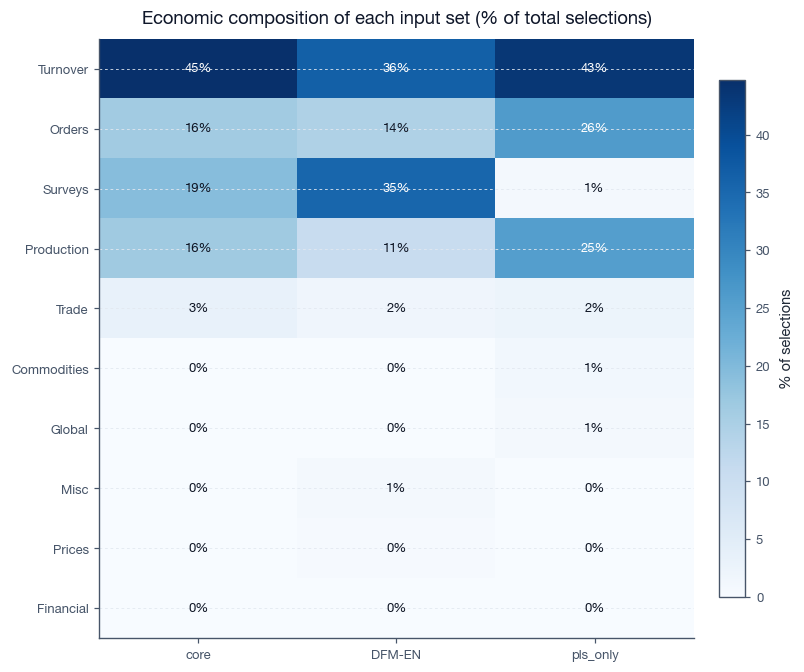

In [10]:
_meta = pd.read_csv(_tp.DATA_DICT_ENRICHED_CSV, usecols=['id', 'category']).set_index('id')
npl.fig_composition_heatmap(
    selection_matrices, _meta,
    save=FIG_DIR / '05_composition_heatmap.png',
);


### 5e. Pairwise Diebold–Mariano matrix

Full $N \times N$ matrix of DM $p$-values (squared-error loss, HLN correction). Saved to `dm_table.csv`.


In [ ]:
# Full pairwise DM matrix (p-values, squared-error loss).
names = list(all_results.keys())
dm_mat = pd.DataFrame(np.eye(len(names)), index=names, columns=names) * np.nan
for a in names:
    for b in names:
        if a == b:
            continue
        e_a, e_b = align_forecast_errors(
            all_results[a], all_results[b], month_in_quarter=HEADLINE_MIQ
        )
        dm_mat.loc[a, b] = diebold_mariano_test(e_a, e_b)['p_value']
dm_mat.round(3).to_csv(_tp.DM_TABLE_CSV)
dm_mat.round(3)

## 6. Category contributions (DFM-EN, 2017–2025)

ifoCAST-style decomposition: monthly M1/M2/M3 re-fits; contributions by indicator category.

* Cached panel: `category_contribs_en_2017_2025.parquet`
* Static heatmap + four interactive HTML panels under `FIG_DIR`


In [12]:
# Build or load cached category contributions (M1/M2/M3, 2017-01 – 2025-12).
meta = pd.read_csv(_tp.DATA_DICT_ENRICHED_CSV, usecols=['id', 'category']).set_index('id')
contrib_cache_df = npl.run_category_contrib_panel(
    selection_matrix=selection_matrices['en_only'],
    X_monthly=X_monthly,
    y_quarterly=y_quarterly,
    meta=meta,
    quarterly_origins=quarterly_origins,
    pub_lag_map=pub_lag_map,
    k_factors=K_FACTORS,
    factor_order=FACTOR_ORDER,
    idiosyncratic_ar1=True,
    maxiter=200,
    m_start='2017-01',
    m_end='2025-12',
    cache_path=_tp.CATEGORY_CONTRIB_CACHE_PARQUET,
    force_rerun=FORCE_RERUN_CONTRIB,
    verbose=True,
)
print(f'Cached origins: {contrib_cache_df["monthly_origin"].nunique()}')


Loaded category contributions from category_contribs_en_2017_2025.parquet
Cached origins: 108


### 6b. Interactive contribution panels

Four sub-period HTML panels (2017–2019, 2020–2021, 2022–2023, 2024–2025).


In [13]:
# Four interactive panels (monthly x-axis); HTML saved under FIG_DIR.
CONTRIB_PERIODS = [
    ('2017-01', '2019-12', '2017_2019'),
    ('2020-01', '2021-12', '2020_2021'),
    ('2022-01', '2023-12', '2022_2023'),
    ('2024-01', '2025-12', '2024_2025'),
]
contrib_figs = npl.fig_category_contrib_period_panels(
    cache_df=contrib_cache_df,
    periods=CONTRIB_PERIODS,
    fig_dir=FIG_DIR,
    base_title='DFM-EN: Category Contributions by Forecast Origin',
)
# HTML panels written under FIG_DIR (see contrib_figs paths)


## 7. Integrated DFM-SV ($k=2$)

Homoskedastic EM-DFM understates uncertainty in turbulent periods. **Integrated SV (Path A):**

1. **EM stage** — fit DFM-EN and extract factor VAR innovations.
2. **SV stage** — diagonal AR(1) log-SV on factor innovations (Kim, Shephard & Chib 1998; NumPyro NUTS).
3. **Re-smooth** — inject time-varying factor-innovation covariance $Q_t$ into the Kalman smoother; the point nowcast **can differ** from plain DFM-EN (mostly in high-volatility episodes).

Only **$k = 2$** is run here (headline distributional model). Loads `nowcast_results_actpn_sv_integrated_k2.csv` if present; re-runs only when missing or `FORCE_RERUN_SV = True`.

> Refresh SV only: `python scripts/rerun_sv_integrated.py`

### 7a. Run / load SV nowcasts


In [ ]:
# Integrated DFM-SV-k2 on EN inputs (headline distributional model)
from german_gdp_nowcasting.models.dfm.dfm_sv_integrated import (
    run_actpn_nowcast_loop_sv_integrated,
)
SV_K_FACTORS = 2
if _needs_run_sv(_tp.ACTPN_SV_RESULTS_K2_CSV):
    sv_k2_df = run_actpn_nowcast_loop_sv_integrated(
        selection_matrix=selection_matrices[HEADLINE_INPUT_SET],
        X_monthly=X_monthly,
        y_quarterly=y_quarterly,
        quarterly_origins=quarterly_origins,
        factor_order=FACTOR_ORDER,
        idiosyncratic_ar1=True,
        maxiter=200,
        k_factors=SV_K_FACTORS,
        pub_lag_map=pub_lag_map,
        num_warmup=500,
        num_samples=1000,
        credibility=0.9,
        rng_seed=42,
        n_iter=1,
        save_path=_tp.ACTPN_SV_RESULTS_K2_CSV,
        verbose=False,
    )
else:
    sv_k2_df = _load_nowcast_csv(_tp.ACTPN_SV_RESULTS_K2_CSV)
print(
    f'DFM-SV-k2  RMSFE M{HEADLINE_MIQ} = {compute_rmsfe(sv_k2_df, month_in_quarter=HEADLINE_MIQ):.4f}'
    f'  |  pooled M1-M3 = {compute_rmsfe(sv_k2_df):.4f}'
)
sv_k2_df.tail()


### 7b. Interval calibration

Summary table at the nominal **90%** level: RMSFE (unchanged from EM), empirical coverage, mean PI width, CRPS.

Full-sample 90% coverage is 53 of 60 (88.3%), close to nominal. That average hides the regime split: 97.2% pre-COVID, 25.0% during COVID (six of eight pandemic outcomes miss) and 100% after 2022. Pooled coverage is not evidence that the bands are honest in the window where they are needed. The figure plots nominal vs empirical coverage and CRPS by nominal level.


In [ ]:
# Interval calibration table + calibration/CRPS figure (headline DFM-SV-k2)
sv_cal = build_interval_calibration_table(
    {'SV_k2': sv_k2_df},
    eval_start=EVAL_START,
    eval_end=EVAL_END,
    credibility=0.9,
)
display(sv_cal)
npl.fig_sv_calibration(
    sv_k2_df,
    model_label=npl.MODEL_LABELS.get('SV_k2', 'DFM-SV (k=2, integrated)'),
    save=FIG_DIR / '09_sv_comparison.png',
);


### 7c. Point-shift diagnostic

Integrated SV re-smooths with time-varying $Q_t$; the point nowcast can differ slightly from the EM baseline (`nowcast_baseline`). Shifts concentrate in high-volatility episodes (e.g. 2020Q2).


In [ ]:
# Sanity check: SV point nowcast equals EM-DFM (PI rescaling only).
_shift = sv_k2_df['point_shift'].abs().dropna() if 'point_shift' in sv_k2_df.columns else pd.Series(dtype=float)
if len(_shift):
    print(f'  mean |Δpoint| = {_shift.mean():.4f} pp  |  max = {_shift.max():.4f} pp')
else:
    print('  [INFO] point_shift column not available — re-run §7 with integrated SV.')


### 7d. Thesis figures

Two panels for the thesis:

* **`06_sv_volatility.png`** — posterior mean relative-volatility multiplier $r_t$ (top) and PI width vs $|\text{error}|$ (bottom).
* **`11_nowcast_fan_sv90.png`** — M3 nowcast with 90% time-varying PI; band widens in turbulent periods (e.g. COVID 2020).


In [ ]:
# Headline distributional model: integrated DFM-SV with k=2.
sv_df = sv_k2_df
npl.fig_sv_volatility(sv_df, save=FIG_DIR / '06_sv_volatility.png');


In [ ]:
# DFM-SV-k2 nowcast with 90% time-varying prediction interval.
# The shaded band widens automatically in turbulent periods (COVID 2020) because it
# is driven by the posterior SV multiplier r_t — not by a constant sigma.
npl.fig_nowcast_fan(sv_df, credibility=0.90, save=FIG_DIR / '11_nowcast_fan_sv90.png');


## 8. Post-notebook workflow (CLI scripts)

The notebook runs core DFM models inline. Additional benchmarks and thesis-wide figures are produced by scripts in `scripts/`:

| Script | Purpose |
|---|---|
| `scripts/pipelines/dfm/rerun_sv_integrated.py` | Refresh integrated DFM-SV ($k=2$) on EN inputs |
| `scripts/pipelines/dfm/run_ifocast_benchmark.py` | Frozen ifoCAST indicator set |
| `scripts/pipelines/dfm/run_blockbalanced_benchmark.py` | Block-balanced $k=20$ DFM |
| `scripts/pipelines/dfm/run_ifocast_regime_combo.py` | Equal-weight average of DFM-EN, block-balanced and ifoCAST |
| `scripts/pipelines/dfm/build_unified_evaluation.py` | RMSFE, DM, MCS, Mincer–Zarnowitz |
| `scripts/pipelines/dfm/run_horizon_profile.py` | M1–M3 profiles by regime |
| `scripts/pipelines/dfm/run_release_block_counterfactual.py` | Post-COVID hard vs non-hard update |
| `scripts/pipelines/dfm/run_all_thesis_figures.py` | Thesis figures |

See `outputs/nowcasting/thesis_evaluation_notes.md` for regime cutoffs and headline model set.
